# Outlier Analysis Visualization
Load `outlier_results.h5` produced by notebook 3 and plot grid-point statistics
as a function of `amp_prefactor` and `charge_gate`.

In [1]:
import os
import xarray as xr
import matplotlib.pyplot as plt
from scqat.parsers.xarray_h5_parser import load_xarray_h5

## 1. Configuration

In [2]:
SHAPE_FOLDERS = {
    "square":     r"D:\SynologyDrive\LiChiehHsiao\AS\SynologyDrive\data\MIST\20260402\ng01_ref0165_test04\square",
    "two_step":   r"D:\SynologyDrive\LiChiehHsiao\AS\SynologyDrive\data\MIST\20260402\ng01_ref0165_test04\two_step",
    "three_step": r"D:\SynologyDrive\LiChiehHsiao\AS\SynologyDrive\data\MIST\20260402\ng01_ref0165_test04\three_step",
    "three_step_uf": r"D:\SynologyDrive\LiChiehHsiao\AS\SynologyDrive\data\MIST\20260402\ng01_ref0165_test04\three_step_uf",
}
output_folder = r"D:\SynologyDrive\LiChiehHsiao\AS\SynologyDrive\data\MIST\20260402\ng01_ref0165_test04"

FIGURE_SAVE_PATH = os.path.join(output_folder, "figures")
os.makedirs(FIGURE_SAVE_PATH, exist_ok=True)

# Normalization factor for amp_prefactor per shape (divide raw values by this)
AMP_PREFACTOR_NORM = {
    "square":     1.0,
    "two_step":   1.0,
    "three_step": 1.0,
    "three_step_uf": 1.0,
}

Saved cross_shape_mean_IQ_distance_vs_amp.png


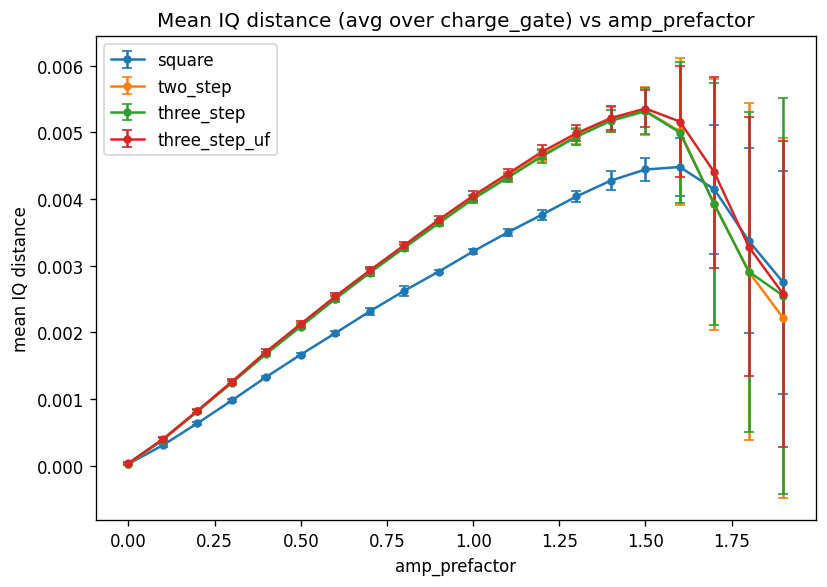

In [3]:
import numpy as np

fig, ax = plt.subplots(figsize=(7, 5), dpi=120)

for label, folder in SHAPE_FOLDERS.items():
    result_ds = load_xarray_h5(os.path.join(folder, "outlier_results.h5"))
    result_ds = result_ds.assign_coords(
        amp_prefactor=result_ds.amp_prefactor * AMP_PREFACTOR_NORM[label]
    )

    delta_I = (result_ds['I_mean_set2'].sel(prepared_state=0)
               - result_ds['I_mean_set2'].sel(prepared_state=1))
    delta_Q = (result_ds['Q_mean_set2'].sel(prepared_state=0)
               - result_ds['Q_mean_set2'].sel(prepared_state=1))
    distance = np.sqrt(delta_I**2 + delta_Q**2)

    mean_dist_vs_amp = distance.mean(dim='charge_gate')
    std_dist_vs_amp = distance.std(dim='charge_gate')
    ax.errorbar(mean_dist_vs_amp.coords['amp_prefactor'].values, mean_dist_vs_amp.values,
                yerr=std_dist_vs_amp.values, marker='o', markersize=4, capsize=3, label=label)

ax.set_xlabel('amp_prefactor')
ax.set_ylabel('mean IQ distance')
ax.set_title('Mean IQ distance (avg over charge_gate) vs amp_prefactor')
ax.legend()
fig.tight_layout()

fname = "cross_shape_mean_IQ_distance_vs_amp.png"
fig.savefig(os.path.join(FIGURE_SAVE_PATH, fname), bbox_inches='tight')
print(f"Saved {fname}")
plt.show()

Saved cross_shape_mean_outlier_prob_state_0.png


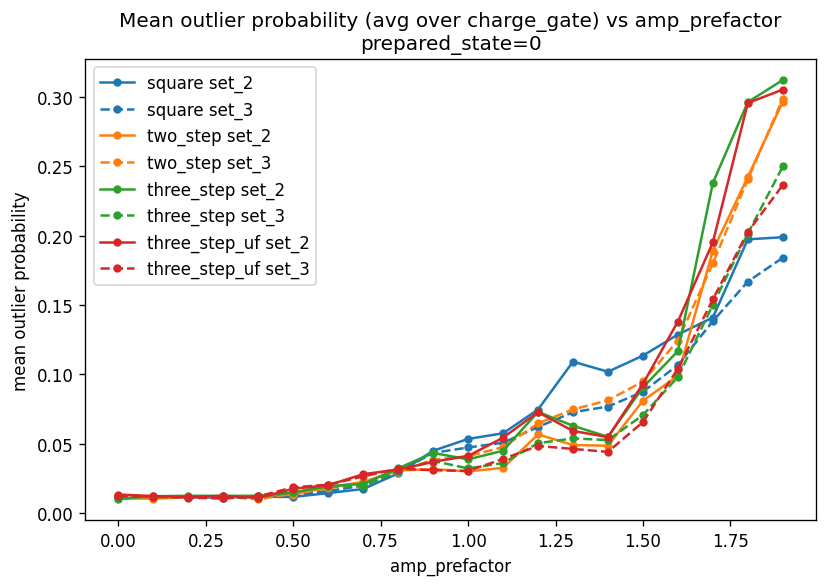

Saved cross_shape_mean_outlier_prob_state_1.png


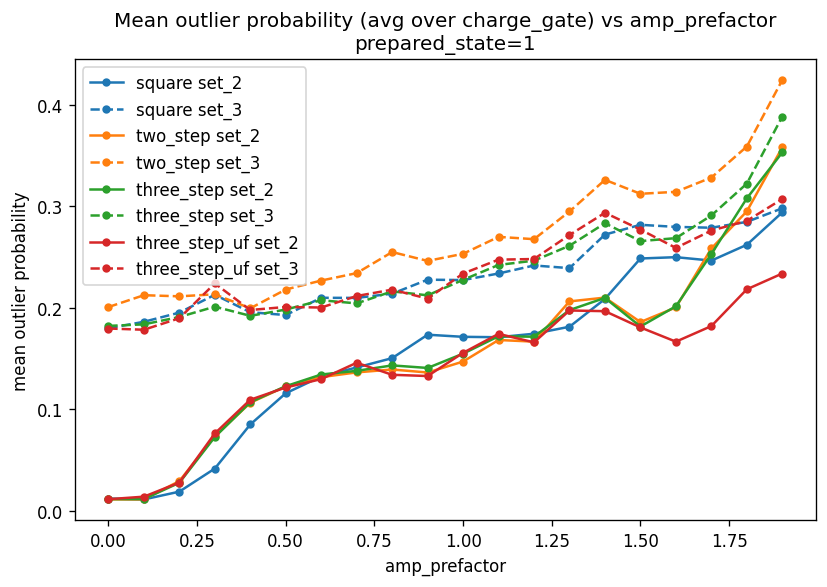

In [8]:
import numpy as np

# Load one dataset to get prepared_state values
sample_ds = load_xarray_h5(os.path.join(next(iter(SHAPE_FOLDERS.values())), "outlier_results.h5"))
prepared_states = sample_ds.coords['prepared_state'].values

# Assign a consistent color per pulse shape
shape_colors = {label: f'C{i}' for i, label in enumerate(SHAPE_FOLDERS)}

for state in prepared_states:
    fig, ax = plt.subplots(figsize=(7, 5), dpi=120)

    for label, folder in SHAPE_FOLDERS.items():
        result_ds = load_xarray_h5(os.path.join(folder, "outlier_results.h5"))
        result_ds = result_ds.assign_coords(
            amp_prefactor=result_ds.amp_prefactor * AMP_PREFACTOR_NORM[label]
        )
        color = shape_colors[label]
        for var_name, set_label, ls in [('outlier_probability_set2', 'set_2', '-'),
                                         ('outlier_probability_set3', 'set_3', '--')]:
            data = result_ds[var_name].sel(prepared_state=state)
            mean_outlier = data.mean(dim='charge_gate')
            ax.plot(mean_outlier.coords['amp_prefactor'].values, mean_outlier.values,
                    marker='o', markersize=4, linestyle=ls,
                    color=color, label=f'{label} {set_label}')

    # ax.set_yscale('log')
    ax.set_xlabel('amp_prefactor')
    ax.set_ylabel('mean outlier probability')
    ax.set_title(f'Mean outlier probability (avg over charge_gate) vs amp_prefactor\n'
                 f'prepared_state={int(state)}')
    ax.legend()
    fig.tight_layout()

    fname = f"cross_shape_mean_outlier_prob_state_{int(state)}.png"
    fig.savefig(os.path.join(FIGURE_SAVE_PATH, fname), bbox_inches='tight')
    print(f"Saved {fname}")
    plt.show()

Saved cross_shape_outlier_over_distance_state_0.png


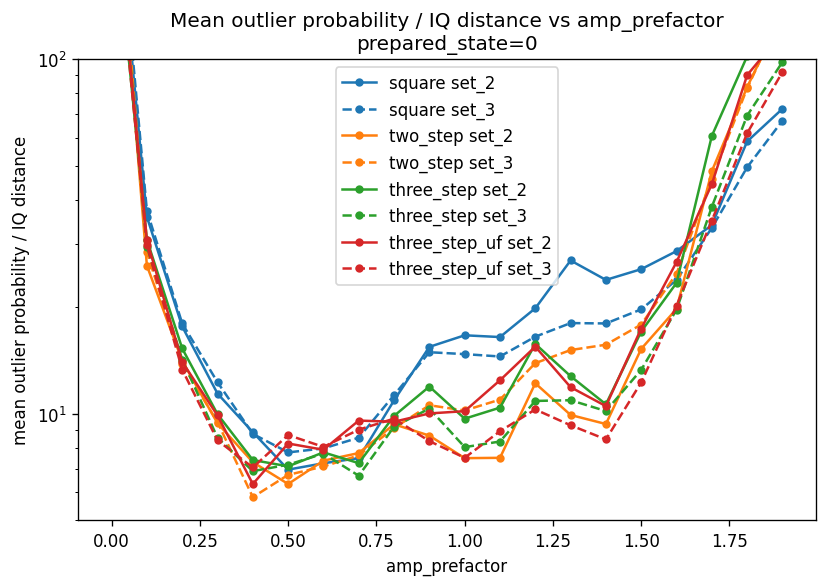

Saved cross_shape_outlier_over_distance_state_1.png


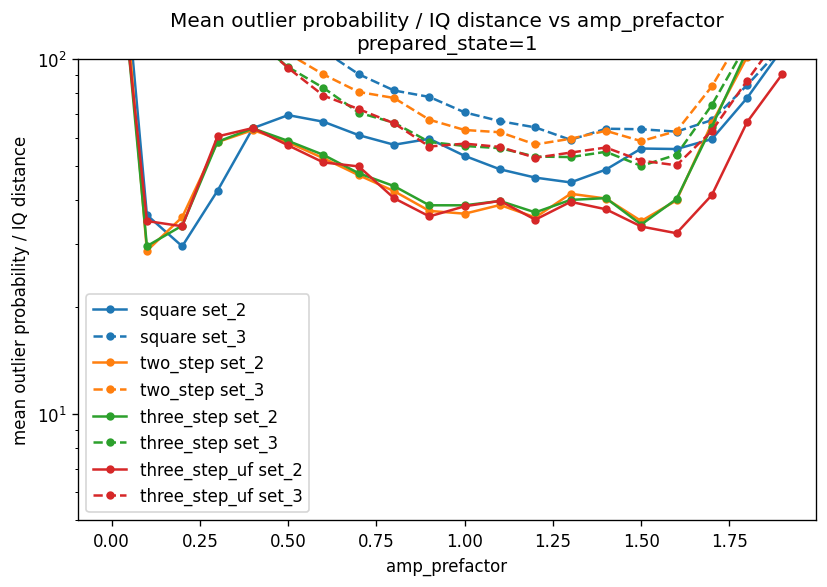

In [5]:
# Mean outlier probability / IQ distance, averaged along charge_gate vs amp_prefactor

for state in prepared_states:
    fig, ax = plt.subplots(figsize=(7, 5), dpi=120)

    for label, folder in SHAPE_FOLDERS.items():
        result_ds = load_xarray_h5(os.path.join(folder, "outlier_results.h5"))
        result_ds = result_ds.assign_coords(
            amp_prefactor=result_ds.amp_prefactor / AMP_PREFACTOR_NORM[label]
        )
        color = shape_colors[label]

        # IQ distance (same as cell 5)
        delta_I = (result_ds['I_mean_set2'].sel(prepared_state=0)
                   - result_ds['I_mean_set2'].sel(prepared_state=1))
        delta_Q = (result_ds['Q_mean_set2'].sel(prepared_state=0)
                   - result_ds['Q_mean_set2'].sel(prepared_state=1))
        distance = np.sqrt(delta_I**2 + delta_Q**2)
        mean_dist = distance.mean(dim='charge_gate')

        for var_name, set_label, ls in [('outlier_probability_set2', 'set_2', '-'),
                                         ('outlier_probability_set3', 'set_3', '--')]:
            mean_outlier = result_ds[var_name].sel(prepared_state=state).mean(dim='charge_gate')
            ratio = mean_outlier / mean_dist
            ratio.plot.line(ax=ax, marker='o', markersize=4, linestyle=ls,
                            color=color, label=f'{label} {set_label}')

    ax.set_ylim(5, 100)
    ax.set_yscale('log')
    ax.set_xlabel('amp_prefactor')
    ax.set_ylabel('mean outlier probability / IQ distance')
    ax.set_title(f'Mean outlier probability / IQ distance vs amp_prefactor\n'
                 f'prepared_state={int(state)}')
    ax.legend()
    fig.tight_layout()

    fname = f"cross_shape_outlier_over_distance_state_{int(state)}.png"
    fig.savefig(os.path.join(FIGURE_SAVE_PATH, fname), bbox_inches='tight')
    print(f"Saved {fname}")
    plt.show()

Saved cross_shape_outlier_vs_charge_gate_amp0_state_0.png


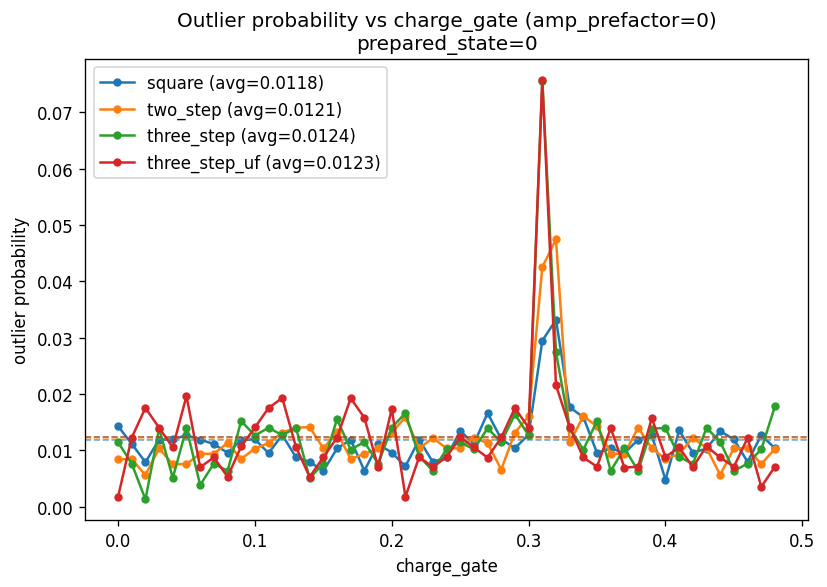

Saved cross_shape_outlier_vs_charge_gate_amp0_state_1.png


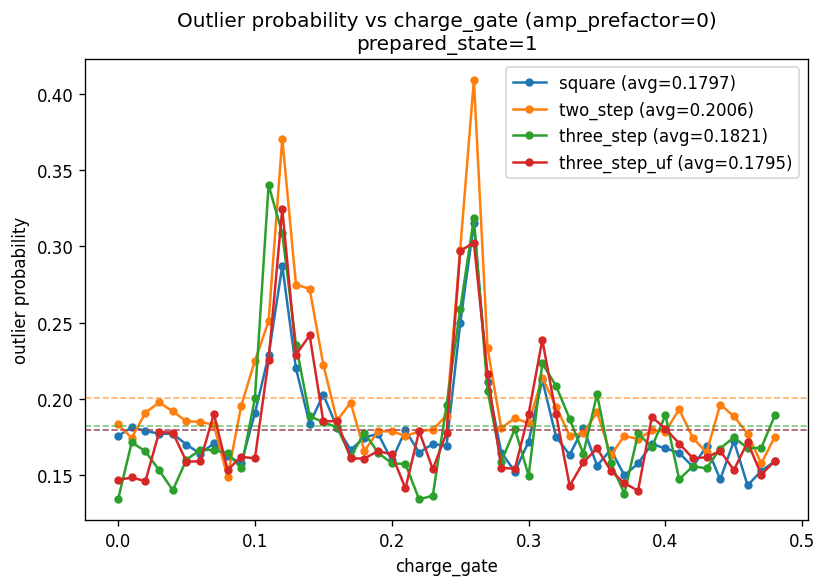

In [6]:
# Outlier probability vs charge_gate at amp_prefactor=0, one figure per prepared_state

for state in prepared_states:
    fig, ax = plt.subplots(figsize=(7, 5), dpi=120)

    for label, folder in SHAPE_FOLDERS.items():
        result_ds = load_xarray_h5(os.path.join(folder, "outlier_results.h5"))
        color = shape_colors[label]

        outlier = result_ds['outlier_probability_set3'].sel(prepared_state=state, amp_prefactor=0, method='nearest')
        mean_val = float(outlier.mean())
        outlier.plot.line(ax=ax, x='charge_gate', marker='o', markersize=4,
                         color=color, label=f'{label} (avg={mean_val:.4f})')
        ax.axhline(mean_val, color=color, linestyle='--', linewidth=1, alpha=0.6)

    ax.set_xlabel('charge_gate')
    ax.set_ylabel('outlier probability')
    ax.set_title(f'Outlier probability vs charge_gate (amp_prefactor=0)\n'
                 f'prepared_state={int(state)}')
    ax.legend()
    fig.tight_layout()

    fname = f"cross_shape_outlier_vs_charge_gate_amp0_state_{int(state)}.png"
    fig.savefig(os.path.join(FIGURE_SAVE_PATH, fname), bbox_inches='tight')
    print(f"Saved {fname}")
    plt.show()

Saved cross_shape_outlier_delta_vs_amp_state_0.png


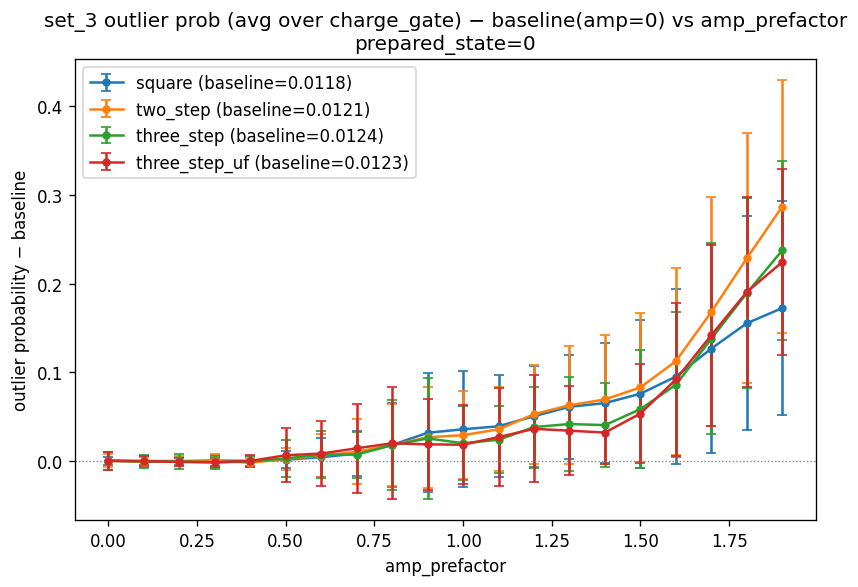

Saved cross_shape_outlier_delta_vs_amp_state_1.png


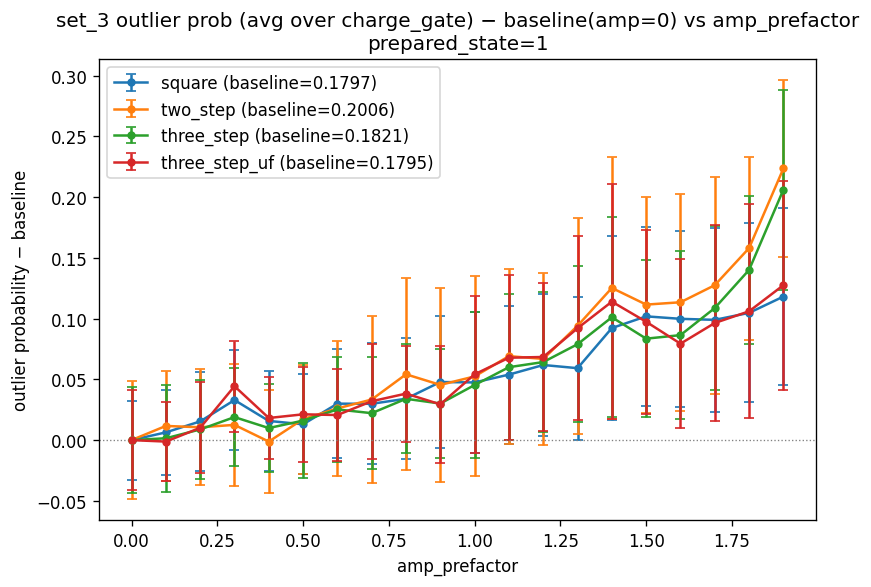

In [7]:
# set_3 outlier probability (avg over charge_gate) minus baseline at amp_prefactor=0, vs amp_prefactor

for state in prepared_states:
    fig, ax = plt.subplots(figsize=(7, 5), dpi=120)

    for label, folder in SHAPE_FOLDERS.items():
        result_ds = load_xarray_h5(os.path.join(folder, "outlier_results.h5"))
        result_ds = result_ds.assign_coords(
            amp_prefactor=result_ds.amp_prefactor * AMP_PREFACTOR_NORM[label]
        )
        color = shape_colors[label]

        outlier_set3 = result_ds['outlier_probability_set3'].sel(prepared_state=state)
        # baseline: mean outlier at amp_prefactor=0 over charge_gate
        baseline = float(outlier_set3.sel(amp_prefactor=0, method='nearest').mean(dim='charge_gate'))
        # mean outlier over charge_gate at each amp_prefactor
        mean_outlier_vs_amp = outlier_set3.mean(dim='charge_gate')
        std_outlier_vs_amp = outlier_set3.std(dim='charge_gate')
        delta = mean_outlier_vs_amp - baseline
        ax.errorbar(delta.coords['amp_prefactor'].values, delta.values,
                    yerr=std_outlier_vs_amp.values, marker='o', markersize=4, capsize=3,
                    color=color, label=f'{label} (baseline={baseline:.4f})')

    ax.axhline(0, color='gray', linestyle=':', linewidth=0.8)
    ax.set_xlabel('amp_prefactor')
    ax.set_ylabel('outlier probability − baseline')
    ax.set_title(f'set_3 outlier prob (avg over charge_gate) − baseline(amp=0) vs amp_prefactor\n'
                 f'prepared_state={int(state)}')
    ax.legend()
    fig.tight_layout()

    fname = f"cross_shape_outlier_delta_vs_amp_state_{int(state)}.png"
    fig.savefig(os.path.join(FIGURE_SAVE_PATH, fname), bbox_inches='tight')
    print(f"Saved {fname}")
    plt.show()